In [ ]:
pip install pandas yfinance stockstats ta matplotlib inline

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=a08bd20e59d043781d0b855099d916a95f9ec97017560aae7204762081a894a6
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
  Created wheel for inline: filename=inline-0.0.1-py3-none-any.whl size=3307 sha256=addfb1c41994cb8d01c700d283b48751e0771a7f34dc3921ab420c48a7c54060
  Stored in directory: /root/.cache/pip/wheels/b3/77/1d/942e15841ad6de1a6a1937dadff4e5df540cb7a0e1f0dcdea4
Successfully built ta inline


In [ ]:
!pip install ta
import pandas as pd
import numpy as np
import yfinance as yf
import ta

# -------------------------------------------
# Download stock data
# -------------------------------------------

symbol = "PFE"

df = yf.download(symbol, start="2012-01-01", end="2024-01-01")

# Reset index
df = df.reset_index()

# Fix MultiIndex columns from yfinance
df.columns = df.columns.get_level_values(0)

# Rename columns
df.rename(columns={
    "Open":"open",
    "High":"high",
    "Low":"low",
    "Close":"close",
    "Volume":"volume"
}, inplace=True)

# Ensure 1D series
for col in ["open","high","low","close","volume"]:
    df[col] = pd.Series(df[col]).astype(float)
# ==========================================
# PART 2 : COMPUTE TECHNICAL INDICATORS
# ==========================================

import ta

# -----------------------------
# TREND INDICATORS
# -----------------------------

df["sma_10"] = df["close"].rolling(10).mean()

df["ema_10"] = df["close"].ewm(span=10).mean()

df["vwma"] = (df["close"] * df["volume"]).rolling(10).sum() / df["volume"].rolling(10).sum()

df["lrma"] = df["close"].rolling(10).mean()

df["kama"] = ta.momentum.KAMAIndicator(df["close"]).kama()

ichimoku = ta.trend.IchimokuIndicator(df["high"], df["low"])

df["ichimoku_a"] = ichimoku.ichimoku_a()
df["ichimoku_b"] = ichimoku.ichimoku_b()

df["eri_bull"] = df["high"] - df["ema_10"]
df["eri_bear"] = df["low"] - df["ema_10"]

df["cti"] = ta.trend.CCIIndicator(df["high"], df["low"], df["close"]).cci()

# -----------------------------
# MOMENTUM INDICATORS
# -----------------------------

df["rsi"] = ta.momentum.RSIIndicator(df["close"]).rsi()

stoch = ta.momentum.StochasticOscillator(df["high"], df["low"], df["close"])

df["stoch_k"] = stoch.stoch()
df["stoch_d"] = stoch.stoch_signal()

df["macd"] = ta.trend.MACD(df["close"]).macd()

df["wr"] = ta.momentum.WilliamsRIndicator(df["high"], df["low"], df["close"]).williams_r()

df["cci"] = ta.trend.CCIIndicator(df["high"], df["low"], df["close"]).cci()

df["trix"] = ta.trend.TRIXIndicator(df["close"]).trix()

df["ppo"] = ta.momentum.PercentagePriceOscillator(df["close"]).ppo()

df["stoch_rsi"] = ta.momentum.StochRSIIndicator(df["close"]).stochrsi()

df["ao"] = ta.momentum.AwesomeOscillatorIndicator(df["high"], df["low"]).awesome_oscillator()

df["roc"] = ta.momentum.ROCIndicator(df["close"]).roc()

df["kst"] = ta.trend.KSTIndicator(df["close"]).kst()

# -----------------------------
# VOLATILITY INDICATORS
# -----------------------------

bb = ta.volatility.BollingerBands(df["close"])

df["bb_high"] = bb.bollinger_hband()
df["bb_low"] = bb.bollinger_lband()

df["atr"] = ta.volatility.AverageTrueRange(df["high"], df["low"], df["close"]).average_true_range()

df["true_range"] = df["high"] - df["low"]

df["mstd"] = df["close"].rolling(10).std()

df["mvar"] = df["close"].rolling(10).var()

# -----------------------------
# VOLUME INDICATORS
# -----------------------------

df["obv"] = ta.volume.OnBalanceVolumeIndicator(df["close"], df["volume"]).on_balance_volume()

df["mfi"] = ta.volume.MFIIndicator(df["high"], df["low"], df["close"], df["volume"]).money_flow_index()

df["bop"] = (df["close"] - df["open"]) / (df["high"] - df["low"])

df["pvo"] = ta.momentum.PercentageVolumeOscillator(df["volume"]).pvo()

# -----------------------------
# OTHER INDICATORS
# -----------------------------

df["dma"] = df["close"].rolling(10).mean() - df["close"].rolling(50).mean()

df["dmi"] = ta.trend.ADXIndicator(df["high"], df["low"], df["close"]).adx()

df["adxr"] = df["dmi"].rolling(10).mean()

df["mad"] = df["close"].rolling(10).apply(lambda x: (x - x.mean()).abs().mean())

df["chop"] = ta.trend.ADXIndicator(df["high"], df["low"], df["close"]).adx()

df["ker"] = abs(df["close"].diff(10)) / df["close"].diff().abs().rolling(10).sum()

df["psl"] = df["close"].diff().apply(lambda x: 1 if x > 0 else 0).rolling(10).mean()

df["vr"] = df["volume"].rolling(10).mean()

df["pg"] = df["close"].pct_change()

df["rvgi"] = (df["close"] - df["open"]) / (df["high"] - df["low"])

df["coppock"] = df["roc"].rolling(10).mean()

# AROON FIXED VERSION
aroon = ta.trend.AroonIndicator(high=df["high"], low=df["low"], window=25)

df["aroon_up"] = aroon.aroon_up()
df["aroon_down"] = aroon.aroon_down()
df["aroon_indicator"] = aroon.aroon_indicator()

# -----------------------------
# CLEAN DATA
# -----------------------------

df = df.dropna().reset_index(drop=True)

print("Indicators added successfully")
print("Dataset shape:", df.shape)
print(df.head())

/tmp/ipykernel_528/62872194.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start="2012-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Indicators added successfully
Dataset shape: (2969, 52)
Price       Date      close       high        low       open      volume  \
0     2012-03-14  11.695176  11.785837  11.673844  11.721841  38693816.0   
1     2012-03-15  11.684512  11.732509  11.631183  11.705844  32575767.0   
2     2012-03-16  11.700514  11.785842  11.668516  11.700514  69272253.0   
3     2012-03-19  11.668517  11.711182  11.636520  11.652519  23501881.0   
4     2012-03-20  11.625852  11.732511  11.604520  11.604520  25468329.0   

Price     sma_10     ema_10       vwma       lrma  ...       chop       ker  \
0      11.490395  11.512768  11.498854  11.490395  ...  15.398999  0.506337   
1      11.512794  11.543996  11.520749  11.512794  ...  16.330121  0.338722   
2      11.541058  11.572454  11.557913  11.541058  ...  17.521240  0.445368   
3      11.561323  11.589921  11.570797  11.561323  ...  18.250766  0.327586   
4      11.589588  11.596454  11.596873  11.589588  ...  18.554668  0.524745   

Price  psl  

Dataset Shape: (2969, 52)

First 5 rows:
Price       Date      close       high        low       open      volume  \
0     2012-03-14  11.695176  11.785837  11.673844  11.721841  38693816.0   
1     2012-03-15  11.684512  11.732509  11.631183  11.705844  32575767.0   
2     2012-03-16  11.700514  11.785842  11.668516  11.700514  69272253.0   
3     2012-03-19  11.668517  11.711182  11.636520  11.652519  23501881.0   
4     2012-03-20  11.625852  11.732511  11.604520  11.604520  25468329.0   

Price     sma_10     ema_10       vwma       lrma  ...       chop       ker  \
0      11.490395  11.512768  11.498854  11.490395  ...  15.398999  0.506337   
1      11.512794  11.543996  11.520749  11.512794  ...  16.330121  0.338722   
2      11.541058  11.572454  11.557913  11.541058  ...  17.521240  0.445368   
3      11.561323  11.589921  11.570797  11.561323  ...  18.250766  0.327586   
4      11.589588  11.596454  11.596873  11.589588  ...  18.554668  0.524745   

Price  psl          vr     

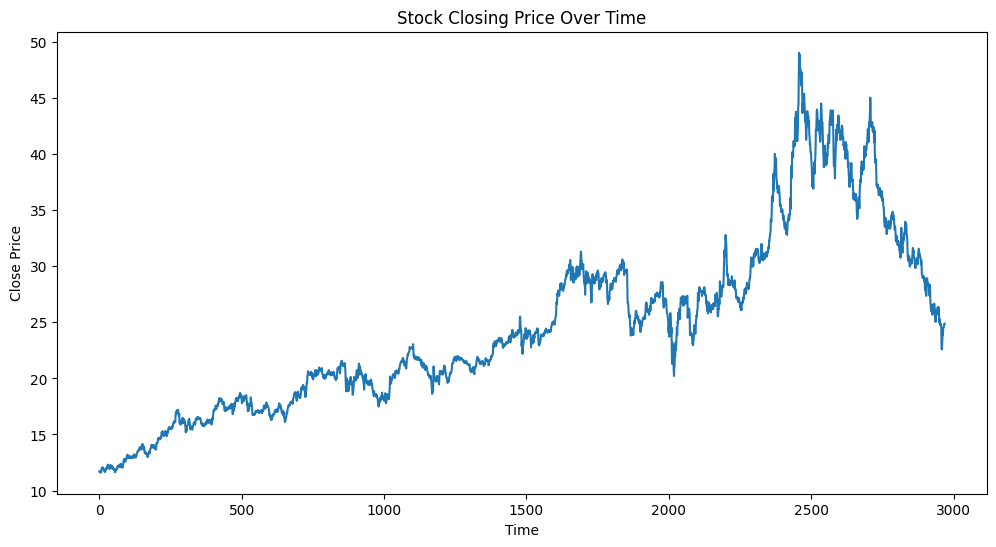

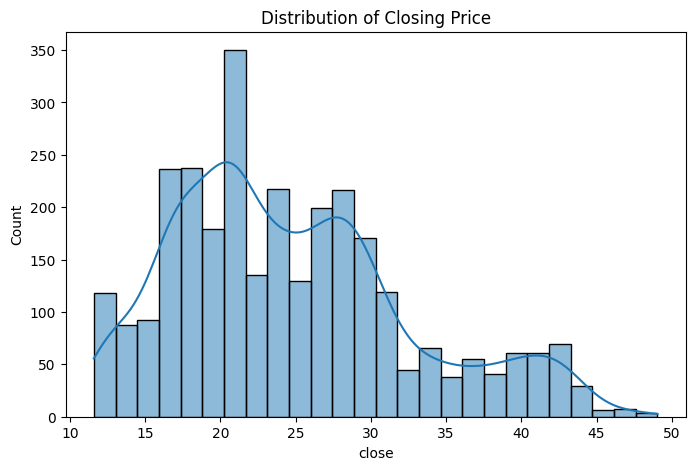

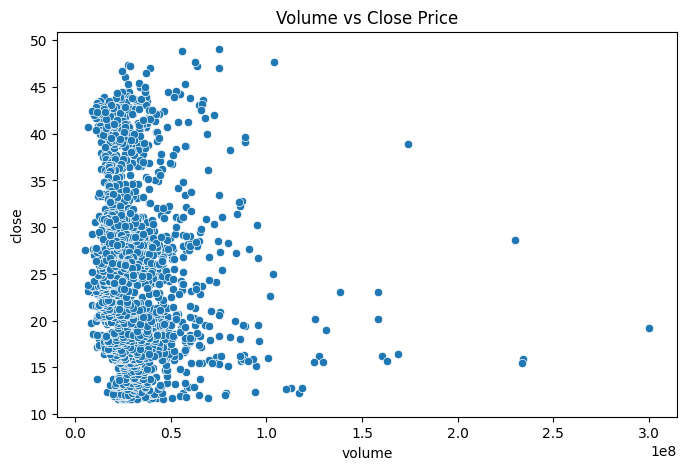

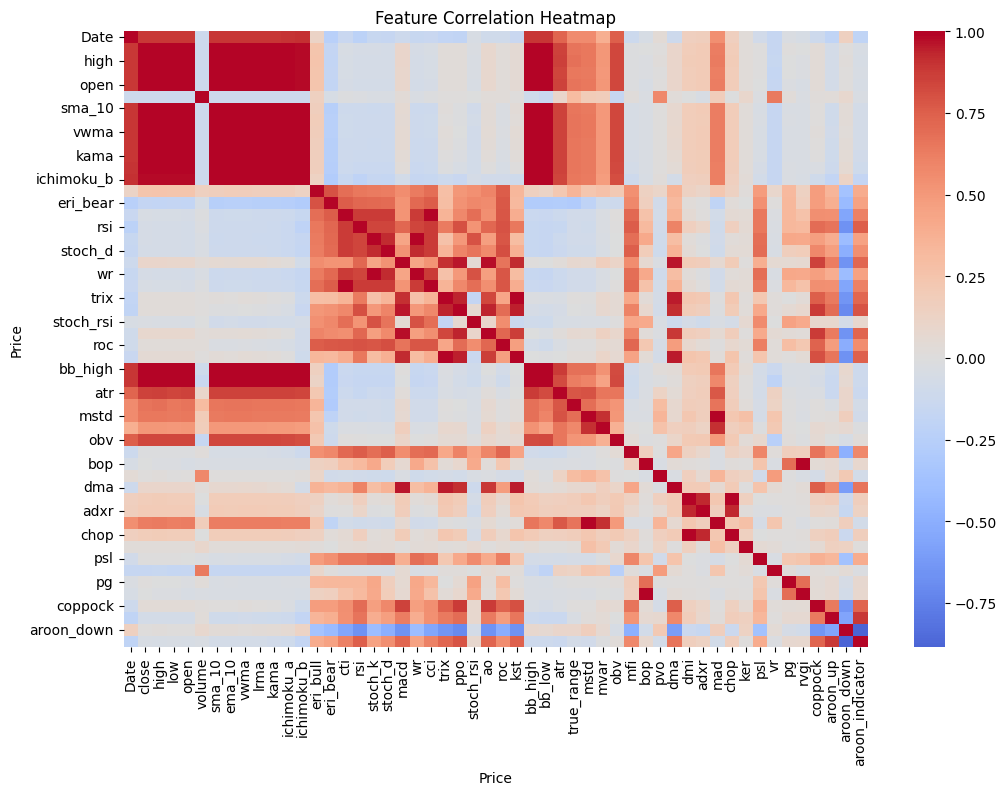


Top Correlated Features with Close Price:
Price
close         1.000000
high          0.999609
low           0.999579
open          0.999136
ema_10        0.997444
vwma          0.996895
lrma          0.996424
sma_10        0.996424
kama          0.996166
ichimoku_a    0.994937
Name: close, dtype: float64


In [ ]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# DATA OVERVIEW
# -----------------------------

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())



# -----------------------------
# CLOSE PRICE OVER TIME
# -----------------------------

plt.figure(figsize=(12,6))

plt.plot(df["close"])

plt.title("Stock Closing Price Over Time")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.show()


# -----------------------------
# DISTRIBUTION OF CLOSE PRICE
# -----------------------------

plt.figure(figsize=(8,5))

sns.histplot(df["close"], kde=True)

plt.title("Distribution of Closing Price")

plt.show()


# -----------------------------
# VOLUME VS CLOSE
# -----------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(x=df["volume"], y=df["close"])

plt.title("Volume vs Close Price")

plt.show()


# -----------------------------
# CORRELATION HEATMAP
# -----------------------------

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()


# -----------------------------
# TOP CORRELATED FEATURES
# -----------------------------

corr_close = corr["close"].sort_values(ascending=False)

print("\nTop Correlated Features with Close Price:")
print(corr_close.head(10))

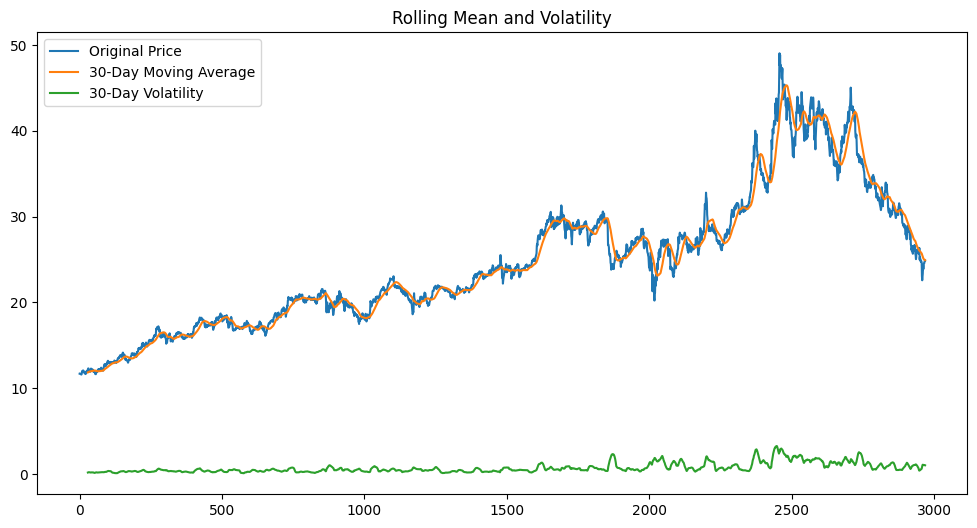

In [ ]:
# ==========================================
# ROLLING MEAN & STANDARD DEVIATION
# ==========================================

plt.figure(figsize=(12,6))

rolling_mean = df["close"].rolling(window=30).mean()
rolling_std = df["close"].rolling(window=30).std()

plt.plot(df["close"], label="Original Price")

plt.plot(rolling_mean, label="30-Day Moving Average")

plt.plot(rolling_std, label="30-Day Volatility")

plt.title("Rolling Mean and Volatility")

plt.legend()

plt.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df["open"],
    high=df["high"],
    low=df["low"],
    close=df["close"]
)])

fig.update_layout(
    title="Stock Candlestick Chart",
    xaxis_title="Time",
    yaxis_title="Price"
)

fig.show()

In [ ]:
# ==========================================
# PART 3 : FEATURE SELECTION + DATA PREP
# ==========================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

# ------------------------------------------
# Remove date column if present
# ------------------------------------------

if "Date" in df.columns:
    df_model = df.drop(columns=["Date"])
else:
    df_model = df.copy()

# ------------------------------------------
# RANDOM FOREST FEATURE SELECTION
# ------------------------------------------

y_rf = df_model["close"]
X_rf = df_model.drop(columns=["close"])

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_rf, y_rf)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_rf.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top important features:")
print(feature_importance.head(20))

# ------------------------------------------
# Select top features
# ------------------------------------------

top_features = feature_importance["Feature"].head(20).tolist()

# add close price back
top_features.append("close")

df_selected = df_model[top_features]

print("Selected features:", df_selected.columns)

# ------------------------------------------
# SCALING
# ------------------------------------------

feature_scaler = MinMaxScaler()
price_scaler = MinMaxScaler()

features = df_selected.copy()

scaled_features = feature_scaler.fit_transform(features)

scaled_close = price_scaler.fit_transform(features[["close"]])

# ------------------------------------------
# SLIDING WINDOW
# ------------------------------------------

window_size = 30

X = []
y = []

for i in range(len(scaled_features) - window_size):

    X.append(scaled_features[i:i+window_size])

    # target is next day close price
    y.append(scaled_close[i+window_size][0])

X = np.array(X)
y = np.array(y).reshape(-1,1)

print("X shape:", X.shape)
print("y shape:", y.shape)

# ------------------------------------------
# TRAIN / VAL / TEST SPLIT
# ------------------------------------------

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.1)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Top important features:
       Feature  Importance
1          low    0.512677
0         high    0.469788
2         open    0.016164
26     bb_high    0.000238
4       sma_10    0.000136
32         obv    0.000093
9   ichimoku_a    0.000093
10  ichimoku_b    0.000088
7         lrma    0.000086
44          pg    0.000058
5       ema_10    0.000057
8         kama    0.000047
43          vr    0.000046
45        rvgi    0.000045
34         bop    0.000045
21         ppo    0.000040
6         vwma    0.000036
17        macd    0.000031
28         atr    0.000020
14         rsi    0.000013
Selected features: Index(['low', 'high', 'open', 'bb_high', 'sma_10', 'obv', 'ichimoku_a',
       'ichimoku_b', 'lrma', 'pg', 'ema_10', 'kama', 'vr', 'rvgi', 'bop',
       'ppo', 'vwma', 'macd', 'atr', 'rsi', 'close'],
      dtype='object', name='Price')
X shape: (2939, 30, 21)
y shape: (2939, 1)
Train shape: (2057, 30, 21)
Validation shape: (293, 30, 21)
Test shape: (589, 30, 21)


In [ ]:
# ==========================================
# PART 4 : MODEL TRAINING
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

# GRU layer
model.add(GRU(128, return_sequences=True,
              input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.2))

# LSTM layer
model.add(LSTM(128))

model.add(Dropout(0.2))

# Dense layers
model.add(Dense(64, activation="relu"))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 128)        │        57,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,889 (773.00 KB)

 Trainable params: 197,889 (773.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0050 - mae: 0.0431 - val_loss: 0.0027 - val_mae: 0.0421
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.7618e-04 - mae: 0.0199 - val_loss: 7.0119e-04 - val_mae: 0.0179
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.0541e-04 - mae: 0.0183 - val_loss: 0.0023 - val_mae: 0.0398
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.9911e-04 - mae: 0.0168 - val_loss: 8.3974e-04 - val_mae: 0.0197
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.2572e-04 - mae: 0.0157 - val_loss: 0.0017 - val_mae: 0.0339
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.5752e-04 - mae: 0.0160 - val_loss: 5.9071e-04 - val_mae: 0.0160
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.3847e-04 - mae: 0.0156 - val_loss: 0.0019 - val_mae: 0.0365
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.7602e-04 - mae: 0.0144 - val_loss: 0.0037 - val_mae: 0.0561
Epoch 9/100
65/65 ━

In [ ]:
# ==========================================
# PART 5 : PREDICTION + COMPLETE EVALUATION
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------------
# PREDICT
# ----------------------------------

gru_lstm_predictions = model.predict(X_test)

# ----------------------------------
# INVERSE SCALING
# ----------------------------------

gru_lstm_predicted_price = price_scaler.inverse_transform(gru_lstm_predictions)
gru_lstm_actual_price = price_scaler.inverse_transform(y_test)

# ----------------------------------
# RESULTS DATAFRAME
# ----------------------------------

gru_lstm_results = pd.DataFrame()

gru_lstm_results["Actual_Price"] = gru_lstm_actual_price.flatten()
gru_lstm_results["Predicted_Price"] = gru_lstm_predicted_price.flatten()

gru_lstm_results["Difference"] = (
    gru_lstm_results["Actual_Price"] - gru_lstm_results["Predicted_Price"]
)

print("\nGRU-LSTM Sample Predictions:")
print(gru_lstm_results.head())

# ----------------------------------
# ERROR METRICS
# ----------------------------------

gru_lstm_mse = mean_squared_error(gru_lstm_actual_price, gru_lstm_predicted_price)

gru_lstm_rmse = np.sqrt(gru_lstm_mse)

gru_lstm_mae = mean_absolute_error(gru_lstm_actual_price, gru_lstm_predicted_price)

gru_lstm_mape = np.mean(
    np.abs((gru_lstm_actual_price - gru_lstm_predicted_price) / gru_lstm_actual_price)
) * 100

# Symmetric MAPE
gru_lstm_smape = np.mean(
    2 * np.abs(gru_lstm_predicted_price - gru_lstm_actual_price) /
    (np.abs(gru_lstm_actual_price) + np.abs(gru_lstm_predicted_price))
) * 100

# R2 score
gru_lstm_r2 = r2_score(gru_lstm_actual_price, gru_lstm_predicted_price)

# ----------------------------------
# ACCURACY WITH ±5% TOLERANCE
# ----------------------------------

gru_lstm_tolerance = 0.05 * gru_lstm_actual_price

gru_lstm_correct_predictions = (
    np.abs(gru_lstm_actual_price - gru_lstm_predicted_price)
    <= gru_lstm_tolerance
)

gru_lstm_accuracy = np.mean(gru_lstm_correct_predictions) * 100

# ----------------------------------
# PRINT RESULTS
# ----------------------------------

print("\nGRU-LSTM Evaluation Metrics")

print("GRU_LSTM_MSE :", gru_lstm_mse)
print("GRU_LSTM_RMSE :", gru_lstm_rmse)
print("GRU_LSTM_MAE :", gru_lstm_mae)
print("GRU_LSTM_MAPE :", gru_lstm_mape, "%")
print("GRU_LSTM_sMAPE :", gru_lstm_smape, "%")
print("GRU_LSTM_R2 Score :", gru_lstm_r2)

print("GRU_LSTM_Accuracy (within ±5% price):", gru_lstm_accuracy, "%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

GRU-LSTM Sample Predictions:
   Actual_Price  Predicted_Price  Difference
0     36.992889        36.113548    0.879341
1     37.119900        35.954784    1.165115
2     36.572147        35.978279    0.593868
3     36.548344        35.850555    0.697788
4     37.183411        35.776546    1.406864

GRU-LSTM Evaluation Metrics
GRU_LSTM_MSE : 3.1491047478258323
GRU_LSTM_RMSE : 1.7745717082794463
GRU_LSTM_MAE : 1.223213030648353
GRU_LSTM_MAPE : 3.1150594341931632 %
GRU_LSTM_sMAPE : 3.1941253490072494 %
GRU_LSTM_R2 Score : 0.9033990646885698
GRU_LSTM_Accuracy (within ±5% price): 78.77758913412563 %


In [ ]:
# ==========================================
# PART 4 : GRU MODEL TRAINING
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

gru_model = Sequential()

# GRU layer
gru_model.add(
    GRU(
        128,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

gru_model.add(Dropout(0.2))

# Dense layers
gru_model.add(Dense(64, activation="relu"))
gru_model.add(Dense(1))

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model.summary()

# Early stopping
gru_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train model
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[gru_early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 128)            │        57,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,305 (259.00 KB)

 Trainable params: 66,305 (259.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0026 - mae: 0.0366 - val_loss: 0.0028 - val_mae: 0.0480
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.4245e-04 - mae: 0.0196 - val_loss: 0.0037 - val_mae: 0.0566
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6632e-04 - mae: 0.0163 - val_loss: 0.0025 - val_mae: 0.0452
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.9159e-04 - mae: 0.0151 - val_loss: 0.0035 - val_mae: 0.0557
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.3991e-04 - mae: 0.0179 - val_loss: 0.0029 - val_mae: 0.0499
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.6588e-04 - mae: 0.0144 - val_loss: 0.0011 - val_mae: 0.0288
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9926e-04 - mae: 0.0130 - val_loss: 0.0012 - val_mae: 0.0306
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.8034e-04 - mae: 0.0126 - val_loss: 7.0383e-04 - val_mae: 0.0209
Epoch 9/100
65/65 ━━━━━━━━━━━━

In [ ]:
# ==========================================
# GRU MODEL : PREDICTION + EVALUATION
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------------
# PREDICT
# ----------------------------------

gru_predictions = gru_model.predict(X_test)

# ----------------------------------
# INVERSE SCALING
# ----------------------------------

gru_predicted_price = price_scaler.inverse_transform(gru_predictions)
gru_actual_price = price_scaler.inverse_transform(y_test)

# ----------------------------------
# RESULTS DATAFRAME
# ----------------------------------

gru_results = pd.DataFrame()

gru_results["Actual_Price"] = gru_actual_price.flatten()
gru_results["Predicted_Price"] = gru_predicted_price.flatten()

gru_results["Difference"] = (
    gru_results["Actual_Price"] - gru_results["Predicted_Price"]
)

print("\nGRU Sample Predictions:")
print(gru_results.head())

# ----------------------------------
# ERROR METRICS
# ----------------------------------

gru_mse = mean_squared_error(gru_actual_price, gru_predicted_price)

gru_rmse = np.sqrt(gru_mse)

gru_mae = mean_absolute_error(gru_actual_price, gru_predicted_price)

gru_mape = np.mean(
    np.abs((gru_actual_price - gru_predicted_price) / gru_actual_price)
) * 100

gru_smape = np.mean(
    2 * np.abs(gru_predicted_price - gru_actual_price) /
    (np.abs(gru_actual_price) + np.abs(gru_predicted_price))
) * 100

gru_r2 = r2_score(gru_actual_price, gru_predicted_price)

# ----------------------------------
# ACCURACY WITH ±5% TOLERANCE
# ----------------------------------

gru_tolerance = 0.03 * gru_actual_price

gru_correct_predictions = (
    np.abs(gru_actual_price - gru_predicted_price)
    <= gru_tolerance
)

gru_accuracy = np.mean(gru_correct_predictions) * 100

# ----------------------------------
# PRINT RESULTS
# ----------------------------------

print("\nGRU Evaluation Metrics")

print("GRU_MSE :", gru_mse)
print("GRU_RMSE :", gru_rmse)
print("GRU_MAE :", gru_mae)
print("GRU_MAPE :", gru_mape, "%")
print("GRU_sMAPE :", gru_smape, "%")
print("GRU_R2 Score :", gru_r2)

print("GRU_Accuracy (within ±5% price):", gru_accuracy, "%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

GRU Sample Predictions:
   Actual_Price  Predicted_Price  Difference
0     36.992889        35.904945    1.087944
1     37.119900        35.529030    1.590870
2     36.572147        35.730228    0.841919
3     36.548344        35.397938    1.150406
4     37.183411        35.292828    1.890583

GRU Evaluation Metrics
GRU_MSE : 2.4059634798336402
GRU_RMSE : 1.551116849187591
GRU_MAE : 1.2184562294511527
GRU_MAPE : 3.1633640514862 %
GRU_sMAPE : 3.236988706543273 %
GRU_R2 Score : 0.9261954297844375
GRU_Accuracy (within ±5% price): 52.29202037351443 %


In [ ]:
# ==========================================
# PART 4 : LSTM MODEL TRAINING
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential()

# LSTM layer
lstm_model.add(
    LSTM(
        128,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

lstm_model.add(Dropout(0.2))

# Dense layers
lstm_model.add(Dense(64, activation="relu"))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

# Early stopping
lstm_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train model
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[lstm_early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        76,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,121 (332.50 KB)

 Trainable params: 85,121 (332.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0039 - mae: 0.0424 - val_loss: 0.0012 - val_mae: 0.0246
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.2426e-04 - mae: 0.0207 - val_loss: 0.0012 - val_mae: 0.0278
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.5511e-04 - mae: 0.0180 - val_loss: 0.0020 - val_mae: 0.0389
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.6193e-04 - mae: 0.0163 - val_loss: 0.0030 - val_mae: 0.0507
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.9132e-04 - mae: 0.0147 - val_loss: 0.0010 - val_mae: 0.0260
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.4282e-04 - mae: 0.0139 - val_loss: 5.2971e-04 - val_mae: 0.0174
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.7128e-04 - mae: 0.0147 - val_loss: 9.5699e-04 - val_mae: 0.0252
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.2962e-04 - mae: 0.0137 - val_loss: 0.0015 - val_mae: 0.0346
Epoch 9/100
65/65 ━━━━━━

In [ ]:
# ==========================================
# LSTM MODEL : PREDICTION + EVALUATION
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------------
# PREDICT
# ----------------------------------

lstm_predictions = lstm_model.predict(X_test)

# ----------------------------------
# INVERSE SCALING
# ----------------------------------

lstm_predicted_price = price_scaler.inverse_transform(lstm_predictions)
lstm_actual_price = price_scaler.inverse_transform(y_test)

# ----------------------------------
# RESULTS DATAFRAME
# ----------------------------------

lstm_results = pd.DataFrame()

lstm_results["Actual_Price"] = lstm_actual_price.flatten()
lstm_results["Predicted_Price"] = lstm_predicted_price.flatten()

lstm_results["Difference"] = (
    lstm_results["Actual_Price"] - lstm_results["Predicted_Price"]
)

print("\nLSTM Sample Predictions:")
print(lstm_results.head())

# ----------------------------------
# ERROR METRICS
# ----------------------------------

lstm_mse = mean_squared_error(lstm_actual_price, lstm_predicted_price)

lstm_rmse = np.sqrt(lstm_mse)

lstm_mae = mean_absolute_error(lstm_actual_price, lstm_predicted_price)

lstm_mape = np.mean(
    np.abs((lstm_actual_price - lstm_predicted_price) / lstm_actual_price)
) * 100

lstm_smape = np.mean(
    2 * np.abs(lstm_predicted_price - lstm_actual_price) /
    (np.abs(lstm_actual_price) + np.abs(lstm_predicted_price))
) * 100

lstm_r2 = r2_score(lstm_actual_price, lstm_predicted_price)

# ----------------------------------
# ACCURACY (±5% tolerance)
# ----------------------------------

lstm_tolerance = 0.03 * lstm_actual_price

lstm_correct_predictions = (
    np.abs(lstm_actual_price - lstm_predicted_price)
    <= lstm_tolerance
)

lstm_accuracy = np.mean(lstm_correct_predictions) * 100

# ----------------------------------
# PRINT RESULTS
# ----------------------------------

print("\nLSTM Evaluation Metrics")

print("LSTM_MSE :", lstm_mse)
print("LSTM_RMSE :", lstm_rmse)
print("LSTM_MAE :", lstm_mae)
print("LSTM_MAPE :", lstm_mape, "%")
print("LSTM_sMAPE :", lstm_smape, "%")
print("LSTM_R2 Score :", lstm_r2)

print("LSTM_Accuracy (within ±5% price):", lstm_accuracy, "%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

LSTM Sample Predictions:
   Actual_Price  Predicted_Price  Difference
0     36.992889        37.064381   -0.071491
1     37.119900        36.726295    0.393604
2     36.572147        36.945194   -0.373047
3     36.548344        36.614048   -0.065704
4     37.183411        36.522827    0.660583

LSTM Evaluation Metrics
LSTM_MSE : 1.282245029622159
LSTM_RMSE : 1.1323625875231658
LSTM_MAE : 0.791301277173598
LSTM_MAPE : 2.090849476627318 %
LSTM_sMAPE : 2.1149013163260384 %
LSTM_R2 Score : 0.9606662594359711
LSTM_Accuracy (within ±5% price): 76.23089983022071 %


In [ ]:
# ==========================================
# PART 4 : CNN MODEL TRAINING
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

cnn_model = Sequential()

# CNN layer
cnn_model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Dropout(0.2))

cnn_model.add(Flatten())

cnn_model.add(Dense(64, activation="relu"))

cnn_model.add(Dense(1))

cnn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

cnn_model.summary()

# Early stopping
cnn_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train model
cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[cnn_early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,569 (240.50 KB)

 Trainable params: 61,569 (240.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0158 - mae: 0.0851 - val_loss: 0.0026 - val_mae: 0.0372
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022 - mae: 0.0360 - val_loss: 0.0016 - val_mae: 0.0308
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015 - mae: 0.0300 - val_loss: 0.0052 - val_mae: 0.0608
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - mae: 0.0263 - val_loss: 0.0018 - val_mae: 0.0295
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.3687e-04 - mae: 0.0228 - val_loss: 0.0034 - val_mae: 0.0455
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.5454e-04 - mae: 0.0213 - val_loss: 0.0016 - val_mae: 0.0275
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2463e-04 - mae: 0.0196 - val_loss: 0.0020 - val_mae: 0.0311
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.6430e-04 - mae: 0.0184 - val_loss: 0.0027 - val_mae: 0.0379
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

In [ ]:
# ==========================================
# CNN MODEL : PREDICTION + EVALUATION
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------------
# PREDICT
# ----------------------------------

cnn_predictions = cnn_model.predict(X_test)

# ----------------------------------
# INVERSE SCALING
# ----------------------------------

cnn_predicted_price = price_scaler.inverse_transform(cnn_predictions)
cnn_actual_price = price_scaler.inverse_transform(y_test)

# ----------------------------------
# RESULTS DATAFRAME
# ----------------------------------

cnn_results = pd.DataFrame()

cnn_results["Actual_Price"] = cnn_actual_price.flatten()
cnn_results["Predicted_Price"] = cnn_predicted_price.flatten()

cnn_results["Difference"] = (
    cnn_results["Actual_Price"] - cnn_results["Predicted_Price"]
)

print("\nCNN Sample Predictions:")
print(cnn_results.head())

# ----------------------------------
# ERROR METRICS
# ----------------------------------

cnn_mse = mean_squared_error(cnn_actual_price, cnn_predicted_price)

cnn_rmse = np.sqrt(cnn_mse)

cnn_mae = mean_absolute_error(cnn_actual_price, cnn_predicted_price)

cnn_mape = np.mean(
    np.abs((cnn_actual_price - cnn_predicted_price) / cnn_actual_price)
) * 100

cnn_smape = np.mean(
    2 * np.abs(cnn_predicted_price - cnn_actual_price) /
    (np.abs(cnn_actual_price) + np.abs(cnn_predicted_price))
) * 100

cnn_r2 = r2_score(cnn_actual_price, cnn_predicted_price)

# ----------------------------------
# ACCURACY ±5%
# ----------------------------------

cnn_tolerance = 0.05 * cnn_actual_price

cnn_correct_predictions = (
    np.abs(cnn_actual_price - cnn_predicted_price)
    <= cnn_tolerance
)

cnn_accuracy = np.mean(cnn_correct_predictions) * 100

# ----------------------------------
# PRINT RESULTS
# ----------------------------------

print("\nCNN Evaluation Metrics")

print("CNN_MSE :", cnn_mse)
print("CNN_RMSE :", cnn_rmse)
print("CNN_MAE :", cnn_mae)
print("CNN_MAPE :", cnn_mape, "%")
print("CNN_sMAPE :", cnn_smape, "%")
print("CNN_R2 Score :", cnn_r2)

print("CNN_Accuracy (within ±5% price):", cnn_accuracy, "%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

CNN Sample Predictions:
   Actual_Price  Predicted_Price  Difference
0     36.992889        37.448765   -0.455875
1     37.119900        37.256413   -0.136513
2     36.572147        35.852585    0.719563
3     36.548344        36.242817    0.305527
4     37.183411        37.357643   -0.174232

CNN Evaluation Metrics
CNN_MSE : 8.031601138952327
CNN_RMSE : 2.834007963812439
CNN_MAE : 2.448704611060979
CNN_MAPE : 7.079271626737693 %
CNN_sMAPE : 6.800126565511164 %
CNN_R2 Score : 0.7536251588306793
CNN_Accuracy (within ±5% price): 36.16298811544992 %


In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =====================================================
# 1. PREPARE INPUTS
# =====================================================

# TRAIN
X_train_seq = X_train
X_train_dense = X_train[:, -1, :]
X_train_sent = X_train_dense[:, -1].reshape(-1,1)
X_train_dense = np.delete(X_train_dense, -1, axis=1)

# VALIDATION
X_val_seq = X_val
X_val_dense = X_val[:, -1, :]
X_val_sent = X_val_dense[:, -1].reshape(-1,1)
X_val_dense = np.delete(X_val_dense, -1, axis=1)

# TEST
X_test_seq = X_test
X_test_dense = X_test[:, -1, :]
X_test_sent = X_test_dense[:, -1].reshape(-1,1)
X_test_dense = np.delete(X_test_dense, -1, axis=1)

# =====================================================
# 2. BUILD MULTI-HEAD MODEL
# =====================================================

# Input layers
input_seq = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
input_dense = Input(shape=(X_train_dense.shape[1],))
input_sent = Input(shape=(1,))

# GRU head (time patterns)
gru_out = GRU(64)(input_seq)
gru_out = Dropout(0.2)(gru_out)

# Dense head (technical indicators)
dense_out = Dense(32, activation="relu")(input_dense)
dense_out = Dropout(0.2)(dense_out)

# Sentiment head
sent_out = Dense(8, activation="relu")(input_sent)

# Merge
merged = Concatenate()([gru_out, dense_out, sent_out])

# Final layers
x = Dense(32, activation="relu")(merged)
x = Dropout(0.2)(x)

output = Dense(1)(x)

# Model
model_multi = Model(
    inputs=[input_seq, input_dense, input_sent],
    outputs=output
)

model_multi.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_multi.summary()

# =====================================================
# 3. TRAIN MODEL
# =====================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_multi.fit(
    [X_train_seq, X_train_dense, X_train_sent],
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=([X_val_seq, X_val_dense, X_val_sent], y_val),
    callbacks=[early_stop]
)

# =====================================================
# 4. PREDICTION
# =====================================================

pred = model_multi.predict([X_test_seq, X_test_dense, X_test_sent])

# =====================================================
# 5. INVERSE SCALING
# =====================================================

pred_price = price_scaler.inverse_transform(pred)
actual_price = price_scaler.inverse_transform(y_test)

# =====================================================
# 6. METRICS
# =====================================================

mse = mean_squared_error(actual_price, pred_price)
mae = mean_absolute_error(actual_price, pred_price)

mape = np.mean(
    np.abs((actual_price - pred_price) / actual_price)
) * 100

# Accuracy ±5%
tolerance = 0.05 * actual_price

accuracy = np.mean(
    np.abs(actual_price - pred_price) <= tolerance
) * 100

print("\nMULTI-HEAD MODEL RESULTS")
print("MSE :", mse)
print("MAE :", mae)
print("MAPE:", mape, "%")
print("Accuracy (±5%):", accuracy, "%")

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 30, 21)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 64)        │     16,704 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │        672 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 32)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 8)         │         16 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 104)       │          0 │ dropout_5[0][0],  │
│ (Concatenate)       │                   │            │ dropout_6[0][0],  │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      3,360 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         33 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,785 (81.19 KB)

 Trainable params: 20,785 (81.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0106 - mae: 0.0754 - val_loss: 0.0015 - val_mae: 0.0270
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0038 - mae: 0.0465 - val_loss: 0.0042 - val_mae: 0.0589
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0029 - mae: 0.0402 - val_loss: 0.0031 - val_mae: 0.0499
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0024 - mae: 0.0365 - val_loss: 0.0022 - val_mae: 0.0419
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0023 - mae: 0.0350 - val_loss: 0.0021 - val_mae: 0.0404
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019 - mae: 0.0321 - val_loss: 9.4000e-04 - val_mae: 0.0236
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0018 - mae: 0.0309 - val_loss: 0.0011 - val_mae: 0.0268
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0014 - mae: 0.0274 - val_loss: 0.0011 - val_mae: 0.0274
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.00


MODEL COMPARISON TABLE

               MSE      RMSE       MAE      MAPE        R2   Accuracy
LSTM      1.282245  1.132363  0.791301  2.090849  0.960666  76.230900
GRU       2.405963  1.551117  1.218456  3.163364  0.926195  52.292020
CNN       8.031601  2.834008  2.448705  7.079272  0.753625  36.162988
GRU-LSTM  3.149105  1.774572  1.223213  3.115059  0.903399  78.777589


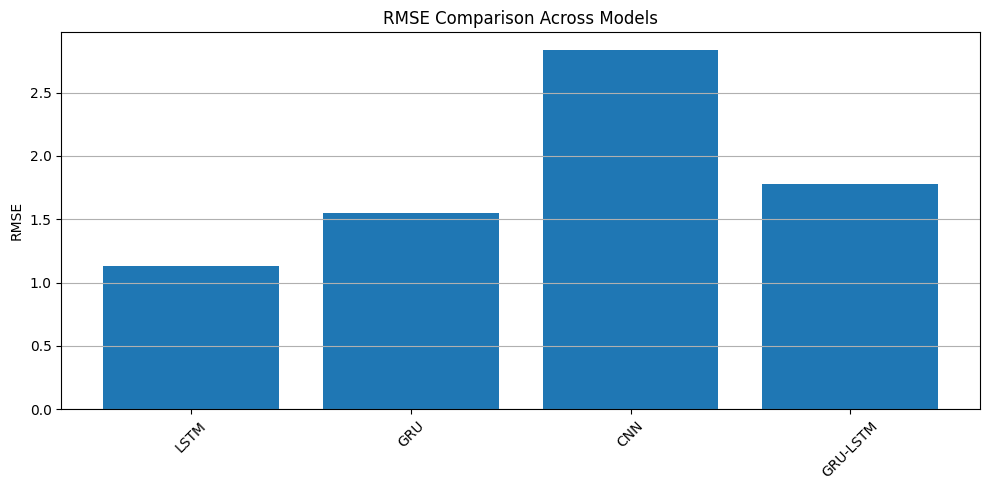

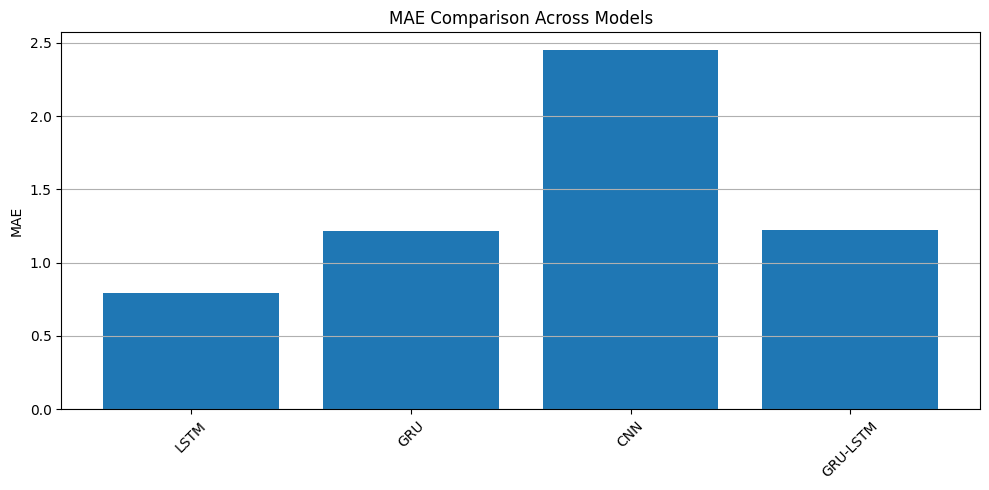

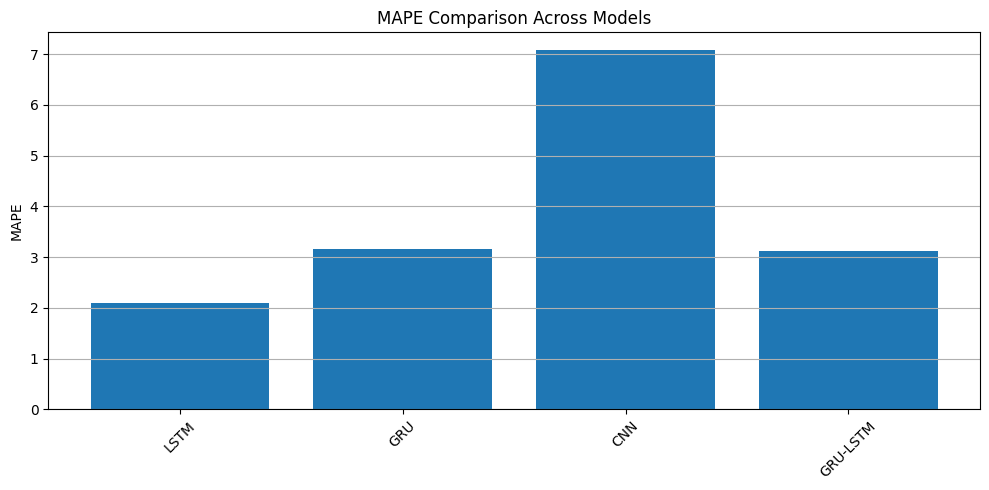

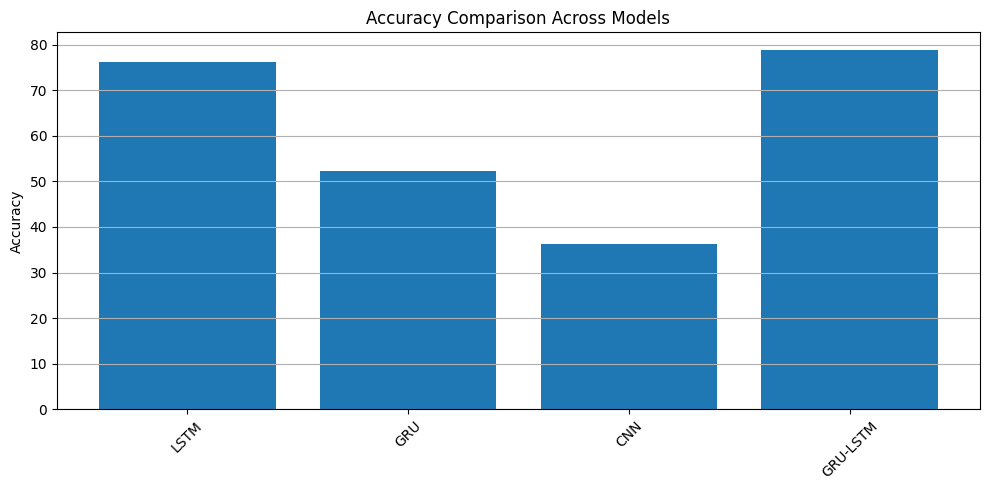

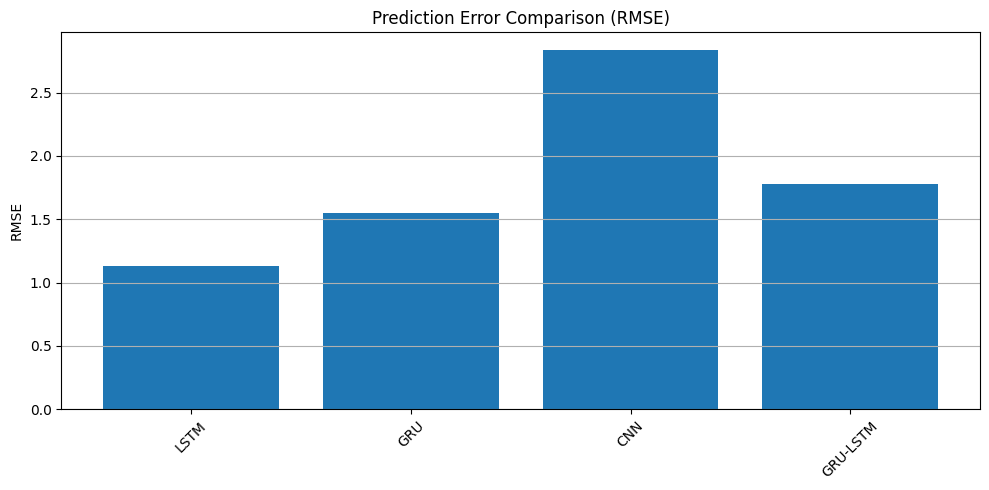


Best Model Based on RMSE: LSTM


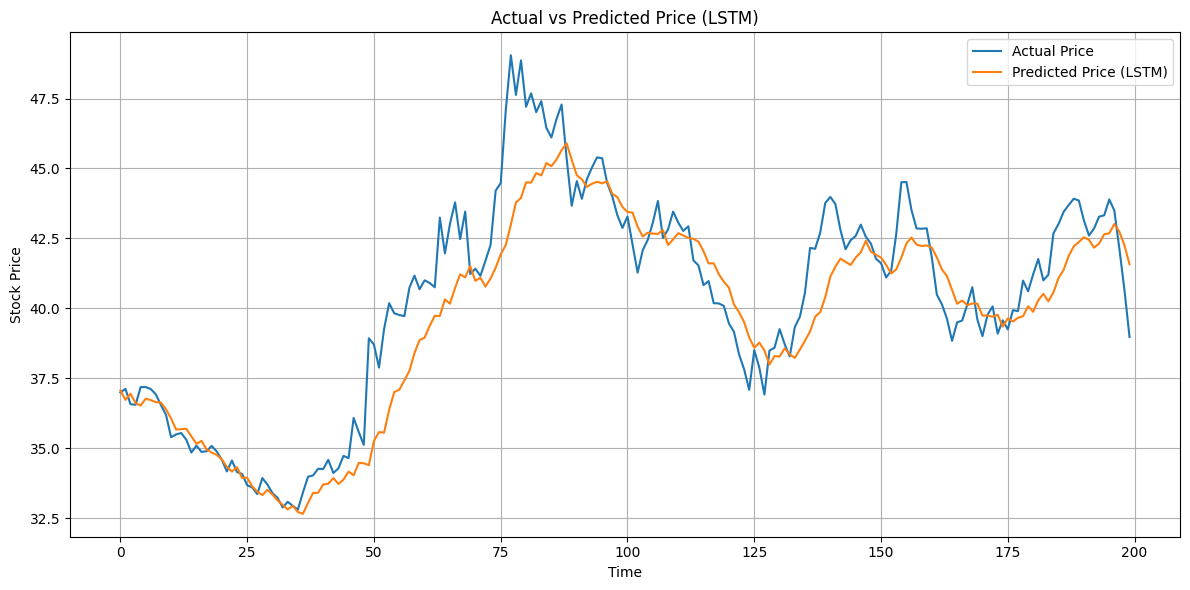

In [ ]:
# ==========================================
# FINAL MODEL COMPARISON + PLOTS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------
# STORE MODEL METRICS
# ----------------------------------

model_metrics = {}

def add_model(name, mse, rmse, mae, mape, r2, acc):
    model_metrics[name] = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Accuracy": acc
    }

# Add models (only if metrics exist)


try:
    add_model("LSTM", lstm_mse, lstm_rmse, lstm_mae, lstm_mape, lstm_r2, lstm_accuracy)
except:
    pass

try:
    add_model("GRU", gru_mse, gru_rmse, gru_mae, gru_mape, gru_r2, gru_accuracy)
except:
    pass

try:
    add_model("CNN", cnn_mse, cnn_rmse, cnn_mae, cnn_mape, cnn_r2, cnn_accuracy)
except:
    pass

try:
    add_model("GRU-LSTM", gru_lstm_mse, gru_lstm_rmse, gru_lstm_mae, gru_lstm_mape, gru_lstm_r2, gru_lstm_accuracy)
except:
    pass



# ----------------------------------
# CREATE COMPARISON DATAFRAME
# ----------------------------------

comparison_df = pd.DataFrame(model_metrics).T

print("\nMODEL COMPARISON TABLE\n")
print(comparison_df)

# ----------------------------------
# BAR CHARTS FOR METRICS
# ----------------------------------

metrics = ["RMSE", "MAE", "MAPE", "Accuracy"]

for metric in metrics:

    plt.figure(figsize=(10,5))

    plt.bar(comparison_df.index, comparison_df[metric])

    plt.title(metric + " Comparison Across Models")

    plt.ylabel(metric)

    plt.xticks(rotation=45)

    plt.grid(axis="y")

    plt.tight_layout()

    plt.show()

# ----------------------------------
# RMSE COMPARISON (ERROR)
# ----------------------------------

plt.figure(figsize=(10,5))

plt.bar(comparison_df.index, comparison_df["RMSE"])

plt.title("Prediction Error Comparison (RMSE)")

plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()


# ----------------------------------
# FIND BEST MODEL
# ----------------------------------

best_model = comparison_df["RMSE"].idxmin()

print("\nBest Model Based on RMSE:", best_model)

# ----------------------------------
# STORE ACTUAL & PREDICTED FOR EACH MODEL
# ----------------------------------

model_predictions = {
    "GRU-LSTM": (gru_lstm_actual_price, gru_lstm_predicted_price),
    "LSTM": (lstm_actual_price, lstm_predicted_price),
    "GRU": (gru_actual_price, gru_predicted_price),
    "CNN": (cnn_actual_price, cnn_predicted_price)
}

# Get predictions of the best model
actual_price, predicted_price = model_predictions[best_model]

# ----------------------------------
# ACTUAL vs PREDICTED PLOT
# ----------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual_price[:200], label="Actual Price")

plt.plot(predicted_price[:200], label=f"Predicted Price ({best_model})")

plt.title(f"Actual vs Predicted Price ({best_model})")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()
